# Finding the yield signal in inspection data

Automated optical inspection (AOI) on a semiconductor assembly & test (OSAT) production line
emits thousands of unit-level pass/fail records a day, each tagged with a defect category, the
machine that ran the lot, and the lot id. The reflex in a production meeting is to chase the
**loudest** defect category — the one with the highest count. This notebook shows why that reflex
misranks the work, and what to rank by instead.

**The dataset is simulated.** `../data/yield_synthetic.csv` is generated by
`../scripts/generate_yield_synthetic.py` with a fixed seed; it reproduces the *phenomena* of an
OSAT inspection line (loud-but-salvageable cosmetic defects, a quieter defect that actually bleeds
yield, a rare defect localized to two machines) without using any production data. The method is
the point, and it transfers directly to a real log with the same columns.

**The metric that matters.** A flagged unit is `recoverable=True` when it was salvaged — reworked
or retested back to a pass, so it cost *no yield*. It is `recoverable=False` (scrapped) when it was
lost. The yield a fix would **recover** for a driver is therefore its scrap count, not its flag
count. Ranking by *recoverable units* — expected yield gained if the driver's root cause is
eliminated — reorders the priority list.

One row per flagged unit; a clean-pass unit generates no row. Inspection lots are a fixed
`UNITS_PER_LOT = 300`, so units-inspected is `lots x 300`.

In [1]:
import numpy as np, pandas as pd, json, pathlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

UNITS_PER_LOT = 300   # fixed AOI inspection-lot size (matches the generator; the yield denominator)

df = pd.read_csv("../data/yield_synthetic.csv", parse_dates=["date"])
df["scrapped"] = ~df.recoverable            # a scrapped unit is a yield loss

n_lots  = df.lot.nunique()
n_units = n_lots * UNITS_PER_LOT
n_flag  = len(df)
n_scrap = int(df.scrapped.sum())
yield_pct = 100 * (1 - n_scrap / n_units)

print(f"window            {df.date.min().date()} -> {df.date.max().date()}  ({df.date.dt.date.nunique()} inspection days)")
print(f"lots inspected    {n_lots:,}   ({df.machine.nunique()} AOI machines)")
print(f"units inspected   {n_units:,}   (= {n_lots:,} lots x {UNITS_PER_LOT})")
print(f"flagged units     {n_flag:,}   ({100*n_flag/n_units:.1f}% of units)")
print(f"scrapped (loss)   {n_scrap:,}   -> overall yield {yield_pct:.2f}%")
print(f"defect categories {df.defect_category.nunique()}")

window            2026-04-06 -> 2026-06-26  (60 inspection days)
lots inspected    2,400   (10 AOI machines)
units inspected   720,000   (= 2,400 lots x 300)
flagged units     133,444   (18.5% of units)
scrapped (loss)   54,358   -> overall yield 92.45%
defect categories 9


## 1 · The naive read — rank by count

Rank the defect categories by how often they are flagged. The top of this list is what the reflex
chases: the loudest category on the floor.

In [2]:
by_count = (df.groupby("defect_category")
              .agg(flag_count=("recoverable", "size"),
                   recoverable_units=("scrapped", "sum"))
              .astype({"recoverable_units": int}))
by_count["scrap_rate_%"] = (100 * by_count.recoverable_units / by_count["flag_count"]).round(1)
by_count = by_count.sort_values("flag_count", ascending=False)
by_count.insert(0, "rank_by_count", range(1, len(by_count) + 1))
loud = by_count.index[0]
print(f'loudest category by count: "{loud}"  ({by_count["flag_count"].iloc[0]:,} flags, '
      f'{by_count["scrap_rate_%"].iloc[0]:.0f}% of them scrapped)\n')
print(by_count[["rank_by_count", "flag_count", "recoverable_units", "scrap_rate_%"]])

loudest category by count: "cosmetic mark"  (35,872 flags, 10% of them scrapped)

                       rank_by_count  flag_count  recoverable_units  \
defect_category                                                       
cosmetic mark                      1       35872               3543   
placement offset                   2       21379              15363   
solder void                        3       17701              10278   
surface contamination              4       17366               2539   
mold flash                         5       13794               1676   
wire bond fault                    6       10190               5622   
die crack                          7        6918               6571   
lead lift                          8        5281               4657   
delamination                       9        4943               4109   

                       scrap_rate_%  
defect_category                      
cosmetic mark                   9.9  
placement offset      

## 2 · Rank by recoverable units — the reorder

Now rank the same categories by **recoverable units** — the scrap each driver causes, i.e. the
yield a root-cause fix would give back. The list reorders. A loud, mostly-salvageable category
sinks; a quieter category with a low salvage rate rises to the top.

In [3]:
rank = by_count.copy()
rank = rank.sort_values("recoverable_units", ascending=False)
rank.insert(1, "rank_by_recoverable", range(1, len(rank) + 1))
rank["rank_delta"] = rank.rank_by_count - rank.rank_by_recoverable   # +ve = rose in priority

lever = rank.index[0]                                  # #1 by recoverable units
jumper = rank.rank_delta.idxmax()                      # biggest climb
faller = rank.rank_delta.idxmin()                      # biggest drop
print(f'top driver by COUNT            : "{loud}"  (rank {int(rank.loc[loud,"rank_by_recoverable"])} by recoverable units)')
print(f'top driver by RECOVERABLE UNITS: "{lever}"  ({int(rank.loc[lever,"recoverable_units"]):,} units; '
      f'rank {int(rank.loc[lever,"rank_by_count"])} by count)')
print(f'biggest climb: "{jumper}"  {int(rank.loc[jumper,"rank_by_count"])} -> {int(rank.loc[jumper,"rank_by_recoverable"])}')
print(f'biggest drop : "{faller}"  {int(rank.loc[faller,"rank_by_count"])} -> {int(rank.loc[faller,"rank_by_recoverable"])}\n')
print(rank[["rank_by_count", "rank_by_recoverable", "rank_delta",
            "flag_count", "recoverable_units", "scrap_rate_%"]])

top driver by COUNT            : "cosmetic mark"  (rank 7 by recoverable units)
top driver by RECOVERABLE UNITS: "placement offset"  (15,363 units; rank 2 by count)
biggest climb: "die crack"  7 -> 3
biggest drop : "cosmetic mark"  1 -> 7

                       rank_by_count  rank_by_recoverable  rank_delta  \
defect_category                                                         
placement offset                   2                    1           1   
solder void                        3                    2           1   
die crack                          7                    3           4   
wire bond fault                    6                    4           2   
lead lift                          8                    5           3   
delamination                       9                    6           3   
cosmetic mark                      1                    7          -6   
surface contamination              4                    8          -4   
mold flash                    

The reorder is the whole finding: the loudest defect on the floor is not the biggest lever on
yield. Counting flags weights every defect equally; weighting by scrap counts only the yield that
is actually lost — and recoverable if fixed.

## 3 · Where does the top driver's loss live — systemic or localized?

Before a meeting acts, it needs to know whether a driver's loss is spread across the line (a
**process** fix) or concentrated on a few machines (a **containment** fix). Two drivers, two
answers: the top lever is diffuse; the rare category is localized.

In [4]:
def machine_share(cat, on="scrapped"):
    sub = df[df.defect_category == cat]
    col = sub.scrapped if on == "scrapped" else pd.Series(True, index=sub.index)
    s = sub[col.values].machine.value_counts()
    return s

lever_m = machine_share(lever)
lever_top_share = 100 * lever_m.iloc[0] / lever_m.sum()
print(f'"{lever}" (top lever): scrap spread over {lever_m.size} machines, '
      f'largest single machine only {lever_top_share:.1f}% -> systemic process loss\n')

localized = "lead lift"       # a rare category whose loss lives on a couple of machines
loc_all = df[df.defect_category == localized].machine.value_counts()
loc_top2 = 100 * loc_all.iloc[:2].sum() / loc_all.sum()
print(f'"{localized}" (rare, {int(rank.loc[localized,"flag_count"]):,} flags): {loc_top2:.1f}% of flags on 2 machines '
      f'({", ".join(loc_all.index[:2])}) -> localized, machine-level containment')
print(loc_all.head(4))

"placement offset" (top lever): scrap spread over 10 machines, largest single machine only 10.9% -> systemic process loss

"lead lift" (rare, 5,281 flags): 92.2% of flags on 2 machines (M03, M07) -> localized, machine-level containment
machine
M03    2515
M07    2353
M09      62
M10      59
Name: count, dtype: int64


## 4 · The table a production meeting can act on

One row per driver, sorted by the metric that matters (recoverable units), carrying the count rank
next to it so the reorder is legible, the scrap rate, and where the loss concentrates.

In [5]:
def concentration(cat):
    s = df[(df.defect_category == cat) & df.scrapped].machine.value_counts()
    top2 = 100 * s.iloc[:2].sum() / s.sum()
    where = f"{s.index[0]}+{s.index[1]} ({top2:.0f}%)"
    return ("localized: " + where) if top2 >= 55 else f"systemic (max {100*s.iloc[0]/s.sum():.0f}%/machine)"

action = rank.copy()
action["yield_pts_recoverable"] = (100 * action.recoverable_units / n_units).round(2)
action["concentration"] = [concentration(c) for c in action.index]
action = action[["rank_by_recoverable", "rank_by_count", "flag_count", "recoverable_units",
                 "yield_pts_recoverable", "scrap_rate_%", "concentration"]]
print(action.to_string())
print(f"\ntotal recoverable if every driver fixed: {action.recoverable_units.sum():,} units "
      f"= {100*action.recoverable_units.sum()/n_units:.2f} yield points")

                       rank_by_recoverable  rank_by_count  flag_count  recoverable_units  yield_pts_recoverable  scrap_rate_%               concentration
defect_category                                                                                                                                          
placement offset                         1              2       21379              15363                   2.13          71.9  systemic (max 11%/machine)
solder void                              2              3       17701              10278                   1.43          58.1  systemic (max 17%/machine)
die crack                                3              7        6918               6571                   0.91          95.0  systemic (max 11%/machine)
wire bond fault                          4              6       10190               5622                   0.78          55.2  systemic (max 16%/machine)
lead lift                                5              8        5281       

## Figures

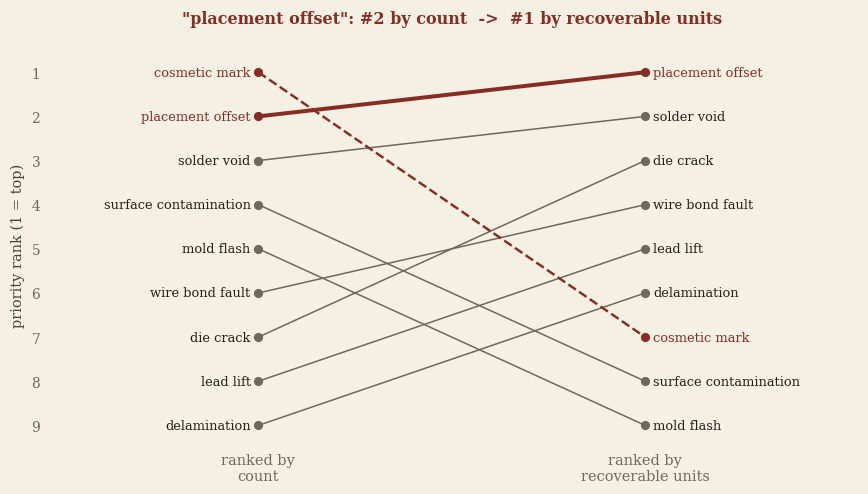

In [6]:
# paper-workbench figure theme (repo DESIGN.md tokens) -- identical to study 01
PAPER, PAPER_DEEP = "#f4f0e4", "#eee8d9"
INK, INK_SOFT, INK_FAINT = "#282018", "#4a4037", "#70675e"
RUBRIC, HAIR = "#872d24", (.16, .13, .09, .28)
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "savefig.facecolor": PAPER,
    "font.family": "serif", "svg.fonttype": "none",
    "text.color": INK, "axes.edgecolor": INK_FAINT, "axes.labelcolor": INK_SOFT,
    "xtick.color": INK_FAINT, "ytick.color": INK_FAINT, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": INK, "grid.alpha": .10, "grid.linewidth": .6,
    "axes.titlesize": 11, "axes.labelsize": 9.5, "figure.dpi": 110,
})
FIGS = pathlib.Path("../docs/figures"); FIGS.mkdir(exist_ok=True)

# Fig 1 -- paired Pareto as a rank slopegraph: the reorder is the story
fig, ax = plt.subplots(figsize=(8, 4.6))
rc = rank.rank_by_count.to_dict()
rr = rank.rank_by_recoverable.to_dict()
hi = (lever, faller)       # the two protagonists: the new #1 lever, and the loud one that falls
for cat in rank.index:
    if cat == lever:       c, lw, z = RUBRIC, 2.6, 5
    elif cat == faller:    c, lw, z = RUBRIC, 1.6, 4
    else:                  c, lw, z = INK_FAINT, 1.0, 2
    ax.plot([0, 1], [rc[cat], rr[cat]], color=c, lw=lw, zorder=z,
            ls=("--" if cat == faller else "-"),
            marker="o", ms=5, mfc=c, mec=c)
    ax.text(-0.02, rc[cat], f"{cat}", ha="right", va="center", fontsize=8.5,
            color=(RUBRIC if cat in hi else INK))
    ax.text(1.02, rr[cat], f"{cat}", ha="left", va="center", fontsize=8.5,
            color=(RUBRIC if cat in hi else INK))
ax.set_title(f'"{lever}": #{rc[lever]} by count  ->  #{rr[lever]} by recoverable units',
             color=RUBRIC, fontsize=10.5, fontweight="bold", pad=12)
ax.set_xlim(-0.55, 1.55); ax.set_ylim(len(rank)+.5, .3)
ax.set_xticks([0, 1]); ax.set_xticklabels(["ranked by\ncount", "ranked by\nrecoverable units"], fontsize=9.5)
ax.set_yticks(range(1, len(rank)+1)); ax.set_ylabel("priority rank (1 = top)")
ax.grid(False); ax.spines["left"].set_visible(False); ax.spines["bottom"].set_visible(False)
ax.tick_params(length=0)
fig.tight_layout(); fig.savefig(FIGS / "yield-fig1.svg"); plt.show()

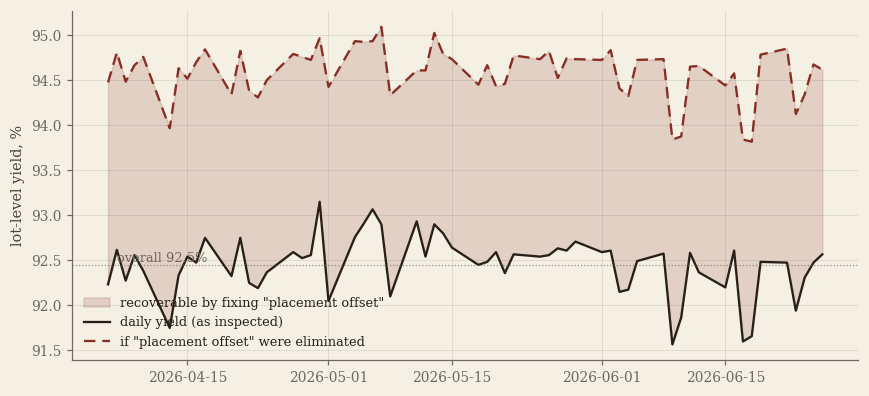

In [7]:
# Fig 2 -- daily yield trend with the top driver's yield-loss contribution shaded
per_day = df.groupby(df.date.dt.date)
lots_day = per_day.lot.nunique() * UNITS_PER_LOT           # units inspected per day
scrap_day = per_day.scrapped.sum()
scrap_lever_day = df[df.defect_category == lever].groupby(df.date.dt.date).scrapped.sum().reindex(scrap_day.index, fill_value=0)

yield_actual = 100 * (1 - scrap_day / lots_day)
yield_wo_lever = 100 * (1 - (scrap_day - scrap_lever_day) / lots_day)
x = pd.to_datetime(scrap_day.index)

fig, ax = plt.subplots(figsize=(8, 3.7))
ax.fill_between(x, yield_actual, yield_wo_lever, color=RUBRIC, alpha=.16,
                label=f'recoverable by fixing "{lever}"')
ax.plot(x, yield_actual, color=INK, lw=1.5, label="daily yield (as inspected)")
ax.plot(x, yield_wo_lever, color=RUBRIC, lw=1.5, ls=(0, (5, 3)),
        label=f'if "{lever}" were eliminated')
ax.axhline(yield_pct, color=INK_FAINT, lw=.8, ls=":", alpha=.7)
ax.annotate(f"overall {yield_pct:.1f}%", (x[1], yield_pct), fontsize=8.5, color=INK_FAINT, va="bottom")
ax.set_ylabel("lot-level yield, %"); ax.legend(frameon=False, fontsize=8.5, loc="lower left", ncol=1)
fig.tight_layout(); fig.savefig(FIGS / "yield-fig2.svg"); plt.show()

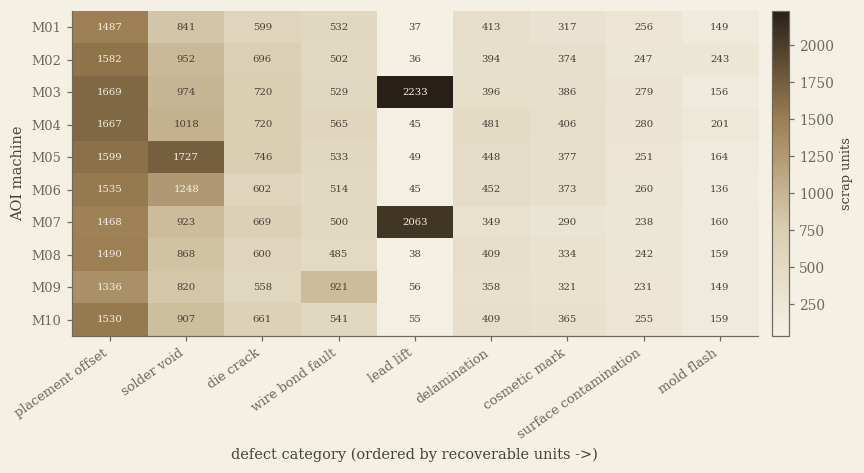

In [8]:
# Fig 3 -- machine x category heatmap of yield-loss (scrap) units, single-hue ink ramp
ink_ramp = LinearSegmentedColormap.from_list("ink", [PAPER, "#d9cdb0", "#9c7f52", INK])
piv = (df[df.scrapped].pivot_table(index="machine", columns="defect_category",
                                   values="scrapped", aggfunc="size", fill_value=0)
       .reindex(index=sorted(df.machine.unique()),
                columns=rank.index))            # columns ordered by recoverable-units rank

fig, ax = plt.subplots(figsize=(8, 4.4))
im = ax.imshow(piv.values, cmap=ink_ramp, aspect="auto")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=35, ha="right", fontsize=8.5)
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index, fontsize=8.5)
vmax = piv.values.max()
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if v > 0:
            ax.text(j, i, f"{v}", ha="center", va="center", fontsize=6.6,
                    color=(PAPER if v > .55 * vmax else INK_SOFT))
ax.set_xlabel("defect category (ordered by recoverable units ->)"); ax.set_ylabel("AOI machine")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=.035, pad=.02); cb.set_label("scrap units", fontsize=8.5)
cb.outline.set_edgecolor(INK_FAINT)
fig.tight_layout(); fig.savefig(FIGS / "yield-fig3.svg"); plt.show()

## Verdict — the loudest defect wasn't the biggest lever

The defect with the highest flag count is not the one bleeding the most yield. Ranking by
**recoverable units** — the scrap a root-cause fix gives back — reorders the priority list and
sends the meeting after a different driver than the count would. The top lever's loss is systemic
(spread across the line, so it's a process fix), while a rare category (lead lift) is localized to
two machines (a containment fix). Same records, two rankings, two very different action lists — and the
recoverable-units ranking is the one tied to yield.

In [9]:
# machine-readable results consumed by the case-study page (docs/)
def row(cat):
    return {"category": cat,
            "rank_by_count": int(rank.loc[cat, "rank_by_count"]),
            "rank_by_recoverable": int(rank.loc[cat, "rank_by_recoverable"]),
            "flags": int(rank.loc[cat, "flag_count"]),
            "recoverable_units": int(rank.loc[cat, "recoverable_units"]),
            "scrap_rate_pct": float(rank.loc[cat, "scrap_rate_%"]),
            "yield_pts_recoverable": round(100 * rank.loc[cat, "recoverable_units"] / n_units, 2)}

results = {
    "synthetic": True,
    "seed": 20260712,
    "window": [str(df.date.min().date()), str(df.date.max().date())],
    "n_days": int(df.date.dt.date.nunique()),
    "n_lots": int(n_lots),
    "units_per_lot": UNITS_PER_LOT,
    "n_units_inspected": int(n_units),
    "n_machines": int(df.machine.nunique()),
    "n_flagged": int(n_flag),
    "n_scrapped": int(n_scrap),
    "flag_rate_pct": round(100 * n_flag / n_units, 1),
    "overall_yield_pct": round(yield_pct, 2),
    "n_categories": int(df.defect_category.nunique()),
    "top_by_count": row(loud),
    "top_by_recoverable": row(lever),
    "biggest_climb": row(jumper),
    "biggest_drop": row(faller),
    "lever_top_machine_share_pct": round(float(lever_top_share), 1),
    "localized_category": localized,
    "localized_flags": int(rank.loc[localized, "flag_count"]),
    "localized_top2_share_pct": round(float(loc_top2), 1),
    "localized_top2_machines": list(loc_all.index[:2]),
    "total_recoverable_units": int(rank.recoverable_units.sum()),
    "total_recoverable_yield_pts": round(100 * rank.recoverable_units.sum() / n_units, 2),
    "drivers": [row(c) for c in rank.sort_values("rank_by_recoverable").index],
}
pathlib.Path("../data/yield_results.json").write_text(json.dumps(results, indent=2))
print(json.dumps({k: results[k] for k in
      ["window","overall_yield_pct","top_by_count","top_by_recoverable","biggest_drop",
       "lever_top_machine_share_pct","localized_category","localized_top2_share_pct"]}, indent=2))

{
  "window": [
    "2026-04-06",
    "2026-06-26"
  ],
  "overall_yield_pct": 92.45,
  "top_by_count": {
    "category": "cosmetic mark",
    "rank_by_count": 1,
    "rank_by_recoverable": 7,
    "flags": 35872,
    "recoverable_units": 3543,
    "scrap_rate_pct": 9.9,
    "yield_pts_recoverable": 0.49
  },
  "top_by_recoverable": {
    "category": "placement offset",
    "rank_by_count": 2,
    "rank_by_recoverable": 1,
    "flags": 21379,
    "recoverable_units": 15363,
    "scrap_rate_pct": 71.9,
    "yield_pts_recoverable": 2.13
  },
  "biggest_drop": {
    "category": "cosmetic mark",
    "rank_by_count": 1,
    "rank_by_recoverable": 7,
    "flags": 35872,
    "recoverable_units": 3543,
    "scrap_rate_pct": 9.9,
    "yield_pts_recoverable": 0.49
  },
  "lever_top_machine_share_pct": 10.9,
  "localized_category": "lead lift",
  "localized_top2_share_pct": 92.2
}
